In [ ]:
# import the necessary libraries
import pandas as pd 
import os
import time
import pandas as pd
import ollama
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random


In [ ]:
# Path of the  data to be labeled(input_data_path)
input_path = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/final_bitcoin_data.csv"
# Path where the results to be saved
output_path = "/Users/jisha/Desktop/Sarcasm_Final/Subreddit_Identification/subreddit_identifications.csv"


In [ ]:
# read the input data to a pandas dataframe and check the information about its contents 
data = pd.read_csv(input_path)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           906 non-null    int64 
 1   comment         906 non-null    object
 2   author          906 non-null    object
 3   subreddit       906 non-null    object
 4   score           906 non-null    int64 
 5   ups             906 non-null    int64 
 6   downs           906 non-null    int64 
 7   date            906 non-null    object
 8   created_utc     906 non-null    object
 9   parent_comment  906 non-null    object
dtypes: int64(4), object(6)
memory usage: 70.9+ KB


In [ ]:
# Load the DataFrame first to prevent NameError
if os.path.exists(output_path):
    predicted_subreddits = pd.read_csv(output_path)
    print(f"Loaded DataFrame directly from existing output file: {output_path}")
else:
    predicted_subreddits = pd.read_csv(input_path)
    print(f"Loaded raw dataset from input path: {input_path}")

# Check if the output CSV exists and check if 'llama_temp1' has existing data to resume from
start_index = 0

if 'llama_temp1' in predicted_subreddits.columns:
    # Count non-null, non-empty predictions to find start row
    subreddit_unidentified_rows = predicted_subreddits['llama_temp1'].dropna()
    subreddit_unidentified_rows = subreddit_unidentified_rows[subreddit_unidentified_rows.astype(str).str.strip() != ""]
    start_index = len(subreddit_unidentified_rows)
    print(f"Found existing 'llama_temp1' column. Resuming from row index {start_index} ({start_index}/{len(predicted_subreddits)} completed).")
else:
    predicted_subreddits['llama_temp1'] = None
    print("Column 'llama_temp1' is missing. Starting subreddit topic prediction from the first row.")

# Initialize or extract existing predictions list
subreddit_list = list(predicted_subreddits['llama_temp1'])

# Start the timer before entering into the loop
start_time = time.time()

# Iterate through DataFrame starting from start_index using tqdm for progress tracking
progress_bar = tqdm(
    range(start_index, len(predicted_subreddits)),
    initial=start_index,
    total=len(predicted_subreddits),
    desc="Processing LLM Topics",
    unit="row"
)

for index in progress_bar:
    row = predicted_subreddits.iloc[index]
    parent_comment = row['parent_comment']
    Response_comment = row['comment']
    
    prompt = f"""
    - Parent: {parent_comment}
    - Comment: {Response_comment}\n
    Read through each comment and parent comment columns in the given dataset and find out the topic discussed in each row and name it in one word. 
    you have to find the a one word topic for each and every parent comment and comment pairs. it should strictly a one word topic. Do not use any punctuation or special characters.
    """
    
    result = ollama.chat(
        model='llama3.2:3b',
        messages=[
            {'role': 'system', 'content': 'Respond with EXACTLY one word. No punctuation.'},
            {'role': 'user', 'content': prompt}
        ],
        options={
            'temperature': 1.0,
            'num_predict': 5  # Prevents unnecessary token generation (significantly speeds up each row)
        },
        keep_alive='1h'  # Keeps the model loaded in VRAM/RAM between rows
    )
    
    original_answer = result['message']['content'].strip()
    
    if original_answer:
        topic = original_answer.split()[0].lower() 
    else:
        topic = "unknown"
        
    # Update position in list and DataFrame column
    if index < len(subreddit_list):
        subreddit_list[index] = topic
    else:
        subreddit_list.append(topic)
        
    predicted_subreddits.at[index, 'llama_temp1'] = topic
    
    # Show the latest predicted topic in the tqdm progress bar status
    progress_bar.set_postfix(last_topic=topic)

    # Periodic auto-save every 50 rows to preserve progress on interruptions
    if (index + 1) % 50 == 0:
        predicted_subreddits.to_csv(output_path, index=False)

end_time = time.time()

# Calculate total time
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)



print(f"\nProcessing Complete! Saved to {output_path}")
print(f"Total time taken for this session: {minutes} minutes and {seconds} seconds.")

Loaded DataFrame directly from existing output file: /Users/jisha/Desktop/Sarcasm_Final/Subreddit_Identification/subreddit_identifications.csv
Found existing 'llama_temp1' column. Resuming from row index 900 (900/906 completed).


Processing LLM Topics: 100%|██████████| 906/906 [00:00<00:00,  7.06row/s, last_topic=mining]  


Processing Complete! Saved to /Users/jisha/Desktop/Sarcasm_Final/Subreddit_Identification/subreddit_identifications.csv
Total time taken for this session: 0 minutes and 0 seconds.


In [5]:
data_to_visualise = pd.read_csv(output_path)

In [6]:
data_to_visualise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   label                906 non-null    int64 
 1   comment              906 non-null    object
 2   author               906 non-null    object
 3   subreddit            906 non-null    object
 4   score                906 non-null    int64 
 5   ups                  906 non-null    int64 
 6   downs                906 non-null    int64 
 7   date                 906 non-null    object
 8   created_utc          906 non-null    object
 9   parent_comment       906 non-null    object
 10  llama_temp0          900 non-null    object
 11  llama_temp1          900 non-null    object
 12  ds_temp1             906 non-null    object
 13  ds_temp0             906 non-null    object
 14  subreddit_predicted  906 non-null    object
dtypes: int64(4), object(11)
memory usage: 106.3+ KB


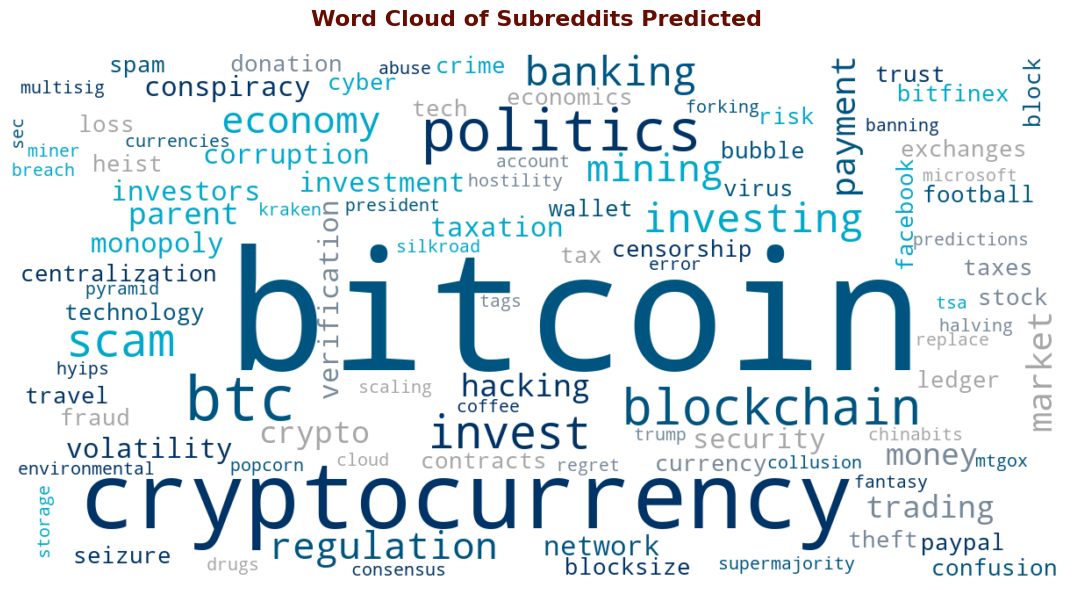

In [ ]:
# Set global Matplotlib font family to clean Sans-Serif (Arial/DejaVu Sans)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# # Use pristine working copy of dataset
# working_df = final_results_cleaned.copy(deep=True)

# Extract and clean text from 'subreddit_predicted'
subreddit_name = " ".join(
    data_to_visualise['llama_temp1']
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
)

# Customise the colours of the texts inside the wordcloud for better visibility 
IMAGE_COLORS = [
    "#003366",  # Dark Navy
    "#00A8CC",  # Bright Cyan / Sky Blue
    "#005580",  # Deep Blue
    "#778899",  # Slate Grey
    "#A6A6A6"   # Soft Grey
]

def customise_word_colour(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(IMAGE_COLORS)

# Generate WordCloud object
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white',       
    color_func=customise_word_colour,   
    collocations=False, 
    max_words=100
).generate(subreddit_name)

# Display Plot
plt.figure(figsize=(12, 6), facecolor='white')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(
    'Word Cloud of Subreddits Predicted', 
    fontsize=16, 
    fontweight='bold', 
    color="#670C00", 
    pad=20
)
plt.tight_layout()
plt.show()